In [15]:
import yfinance

tk = yfinance.Ticker("SPY")
print(tk.options)

('2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [16]:
spot = tk.fast_info['last_price']
print(f"SPY spot: {spot:.2f}")

SPY spot: 710.14


In [17]:
expiries = [
    '2026-04-24',  # ~4 days   — very short dated
    '2026-05-15',  # ~25 days  — 1 month
    '2026-06-18',  # ~2 months
    '2026-09-18',  # ~5 months
    '2026-12-18',  # ~8 months
    '2027-06-17',  # ~14 months — long dated
]

In [25]:
import sys
sys.path.insert(0, '..')
from src.implied_vol import fetch_option_chain, build_iv_surface
import pandas as pd

In [19]:
spot = 710.14
rate = 0.05

# fetch all expiries and concatenate
frames = []
for expiry in expiries:
    try:
        df = fetch_option_chain("SPY", expiry)
        frames.append(df)
        print(f"{expiry}: {len(df)} options fetched")
    except Exception as e:
        print(f"{expiry}: failed — {e}")

all_options = pd.concat(frames, ignore_index=True)
print(f"\nTotal options: {len(all_options)}")
print(all_options.head())

2026-04-24: 264 options fetched
2026-05-15: 321 options fetched
2026-06-18: 248 options fetched
2026-09-18: 235 options fetched
2026-12-18: 278 options fetched
2027-06-17: 302 options fetched

Total options: 1648
   strike      expiry  mid_price option_type  time_to_expiry
0   450.0  2026-04-24    260.720        call        0.008214
1   470.0  2026-04-24    240.735        call        0.008214
2   475.0  2026-04-24    235.735        call        0.008214
3   480.0  2026-04-24    230.745        call        0.008214
4   485.0  2026-04-24    225.750        call        0.008214


Row 0 — strike=450, spot=710, mid_price=260.72. The option is 260 points deep in the money. Its price is almost entirely intrinsic value (710 - 450 = 260). Deep ITM options have very little time value and their IV is numerically unstable — brentq may struggle or return extreme values.
We should filter to a reasonable moneyness range before computing IV. Add this after concatenating:

In [20]:
all_options['moneyness'] = all_options['strike'] / spot
all_options = all_options[
    (all_options['moneyness'] >= 0.7) & 
    (all_options['moneyness'] <= 1.3)
]
print(f"Options after moneyness filter: {len(all_options)}")

Options after moneyness filter: 1123


In [21]:
iv_surface = build_iv_surface(all_options, spot=spot, rate=rate)
print(f"Options with valid IV: {len(iv_surface)}")
print(iv_surface[['strike', 'expiry', 'time_to_expiry', 'implied_vol']].head(10))

Options with valid IV: 1108
    strike      expiry  time_to_expiry  implied_vol
7    500.0  2026-04-24        0.008214     1.735151
8    505.0  2026-04-24        0.008214     1.690255
9    510.0  2026-04-24        0.008214     1.648465
10   515.0  2026-04-24        0.008214     1.609560
11   520.0  2026-04-24        0.008214     1.565668
12   525.0  2026-04-24        0.008214     1.522140
13   530.0  2026-04-24        0.008214     1.481418
14   535.0  2026-04-24        0.008214     1.443291
15   540.0  2026-04-24        0.008214     1.405233
16   545.0  2026-04-24        0.008214     1.360575


### The problem — very short dated deep OTM options
Look at the first expiry, time_to_expiry = 0.008214 years, which is about 3 days. For a 3-day option with strike 500 and spot 710, the option is 29% in the money. The BS model is being asked to fit a price where almost all value is intrinsic - tiny time value, and the IV computation becomes numerically unstable.

#### Two filters to add:

**Filter 1 - minimum time to expiry**

Remove the very short dated expiry entirely. Options with less than 7 days to expiry are numerically unstable:

**Filter 2 - tighter IV bounds after computation**

After building the surface, filter out unreasonable IV values:

In [22]:
# before building surface
all_options = all_options[all_options['time_to_expiry'] > 7/365.25]
print(f"Options after time filter: {len(all_options)}")

# rebuild surface
iv_surface = build_iv_surface(all_options, spot=spot, rate=rate)

# after building surface
iv_surface = iv_surface[
    (iv_surface['implied_vol'] > 0.05) &
    (iv_surface['implied_vol'] < 2.0)
]
iv_surface['moneyness'] = iv_surface['strike'] / spot

print(f"Options with valid IV: {len(iv_surface)}")
print(iv_surface[['strike', 'moneyness', 'expiry', 'time_to_expiry', 'implied_vol']].head(10))

Options after time filter: 866
Options with valid IV: 851
     strike  moneyness      expiry  time_to_expiry  implied_vol
284   500.0   0.704087  2026-05-15        0.065708     0.600762
285   505.0   0.711127  2026-05-15        0.065708     0.584192
286   510.0   0.718168  2026-05-15        0.065708     0.572260
287   515.0   0.725209  2026-05-15        0.065708     0.560238
288   520.0   0.732250  2026-05-15        0.065708     0.546123
289   525.0   0.739291  2026-05-15        0.065708     0.533063
290   530.0   0.746332  2026-05-15        0.065708     0.523703
291   535.0   0.753373  2026-05-15        0.065708     0.511390
292   540.0   0.760413  2026-05-15        0.065708     0.492166
293   545.0   0.767454  2026-05-15        0.065708     0.484184


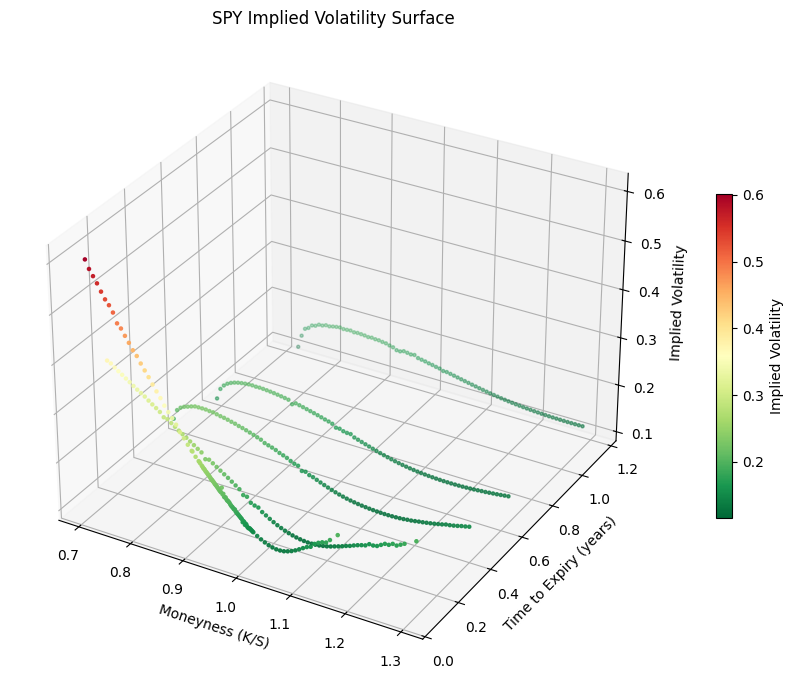

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# use calls only for a clean surface
calls_iv = iv_surface[iv_surface['option_type'] == 'call'].copy()

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    calls_iv['moneyness'],
    calls_iv['time_to_expiry'],
    calls_iv['implied_vol'],
    c=calls_iv['implied_vol'],
    cmap='RdYlGn_r',
    s=5
)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='Implied Volatility')

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('SPY Implied Volatility Surface')

plt.tight_layout()
plt.savefig('../results/03_iv_surface.png', dpi=150)
plt.show()

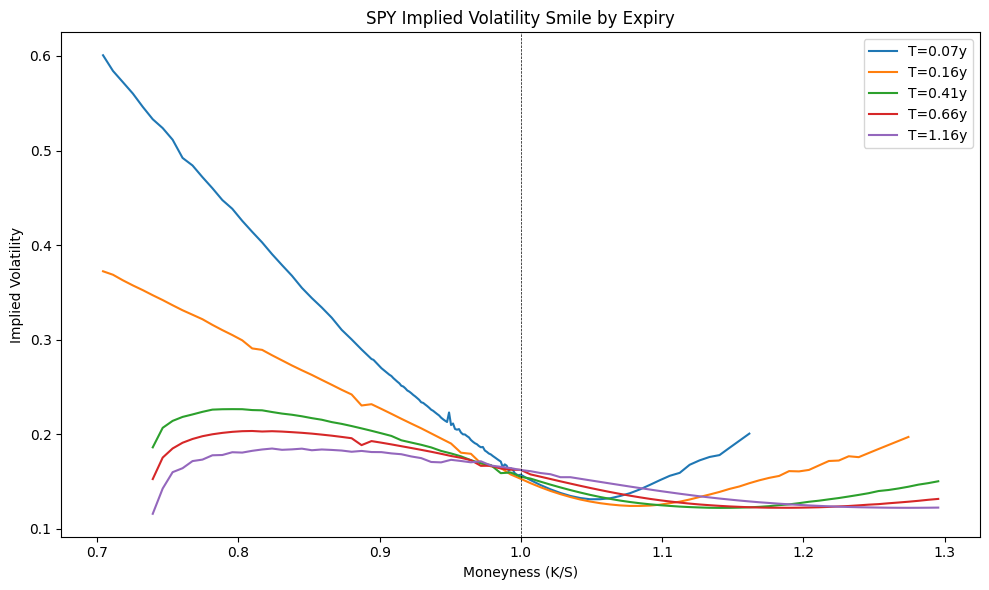

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for expiry in calls_iv['expiry'].unique():
    slice_df = calls_iv[calls_iv['expiry'] == expiry].sort_values('moneyness')
    t = slice_df['time_to_expiry'].iloc[0]
    ax.plot(slice_df['moneyness'], slice_df['implied_vol'], 
            label=f'T={t:.2f}y', linewidth=1.5)

ax.axvline(1.0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title('SPY Implied Volatility Smile by Expiry')
ax.legend()
plt.tight_layout()
plt.show()

**The skew is unmistakable**

Every expiry shows higher IV on the left (OTM puts) than the right (OTM calls). The short-dated blue curve (T=0.07y) is extreme — IV of 0.60 at moneyness 0.70, dropping sharply to 0.16 at ATM. This is the crash risk premium — the market is paying heavily for near-term downside protection right now.

**The smile emerges at longer maturities**

The longer dated curves (green T=0.41y, purple T=1.16y) show a more symmetric smile — IV rises on both sides of ATM. The skew flattens and the right side starts to rise. Long-dated options price in uncertainty in both directions.

**The inverted term structure at OTM puts**

At moneyness 0.75, blue (T=0.07y) has IV≈0.50, orange (T=0.16y) has IV≈0.35, green (T=0.41y) has IV≈0.20. Near-term crash fear dominates. This is a stressed market.

**All curves converge near ATM**

Around moneyness 0.98-1.02 all curves cluster around 0.15-0.17. ATM vol is the anchor — the market agrees on near-term realised vol regardless of expiry.